If you lack an adata file, then you can use the following command or visit [this website](https://data.mendeley.com/datasets/hhny5ff7yj/1) to download it.

```bash
wget -O ./data/ebdata_v3.h5ad https://data.mendeley.com/public-files/datasets/hhny5ff7yj/files/d82698f4-d143-442f-9a41-10be8ad02584/file_downloaded

In [1]:
%load_ext autoreload
%autoreload 2
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
from torchdyn.core import NeuralODE
from tqdm.notebook import tqdm

from scFM_density_estimation.models import *
from scFM_density_estimation.utils import *

In [77]:
def sample_conditional_pt(x0, x1, t, sigma, add_noise):
    mu_t = t * x1 + (1 - t) * x0
    epsilon = torch.randn_like(x0)
    if add_noise:
        return mu_t + sigma * epsilon
    else:
        return mu_t

def one_step(X, C, batch_size, cond_dim, use_ot_sampler, add_noise):
    indices = np.random.randint(X.shape[0], size=batch_size)
    x1 = torch.from_numpy(X[indices]).float().to(device)
    cond = torch.nn.functional.one_hot(torch.from_numpy(C[indices]).long(), num_classes=cond_dim).float().to(device)
    x0 = torch.randn_like(x1).to(device)

    if use_ot_sampler:
        x0, x1, _, cond = ot_sampler.sample_plan_with_labels(x0, x1, y1=cond)

    t = torch.rand(x1.shape[0]).type_as(x1).unsqueeze(1).to(device)
    xt = sample_conditional_pt(x0, x1, t, sigma=0.01, add_noise=add_noise).to(device)
    ut = x1 - x0
    
    vt = model(xt, t, cond)
    return torch.mean((vt - ut) ** 2)

In [20]:
adata = sc.read_h5ad("./data/ebdata_v3.h5ad")

In [170]:
label = "sample_labels" # sample_labels leiden
n_categories = len(adata.obs[label].unique())

coords = adata.obsm["X_phate"]
coords = (coords - coords.mean(axis=0)) / coords.std(axis=0)
adata.obsm["X_phate_standardized"] = coords
X = adata.obsm["X_phate_standardized"]
C = adata.obs[label].cat.codes.values

In [179]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 256
sigma = 0.1
dim = 2
cond_dim = np.max(C) + 1
add_noise = False
use_ot_sampler = False
model = ConditionalFlowMatchingMLP(input_dim=dim, hidden_dims=[64, 64, 64],
                                   cond_dim=cond_dim, use_encoder=False).to(device)
optimizer = torch.optim.Adam(model.parameters())
ot_sampler = OTPlanSampler(method="exact")

for k in tqdm(range(50000)):
    optimizer.zero_grad()

    loss = one_step(X, C, batch_size, cond_dim, use_ot_sampler, add_noise)
    
    loss.backward()
    optimizer.step()

    if (k + 1) % 10000 == 0:
        print(f"{k+1}: loss {loss.item():0.3f}")

  0%|          | 0/50000 [00:00<?, ?it/s]

10000: loss 0.926
20000: loss 1.032
30000: loss 0.860
40000: loss 0.791
50000: loss 1.014


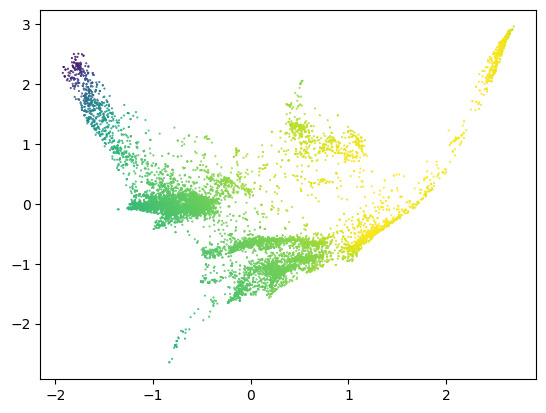

In [189]:
data = adata.obsm["X_phate_standardized"]
indices = np.random.randint(data.shape[0], size=10000)
data = torch.from_numpy(data[indices]).float()

condition = 0
node = NeuralODE(
    cond_torch_wrapper(model, condition, cond_dim), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)
with torch.no_grad():
    traj = node.trajectory(
        data.to(device),
        t_span=torch.linspace(1, 0, 200).to(device),
    )

z0 = traj[-1]
log_p0 = -0.5 * (z0 ** 2).sum(dim=1) - 0.5 * z0.shape[1] * np.log(2 * np.pi)

plt.scatter(x=data[:, 0], y=data[:, 1], c=log_p0.cpu().numpy(), s=0.25, cmap='viridis')

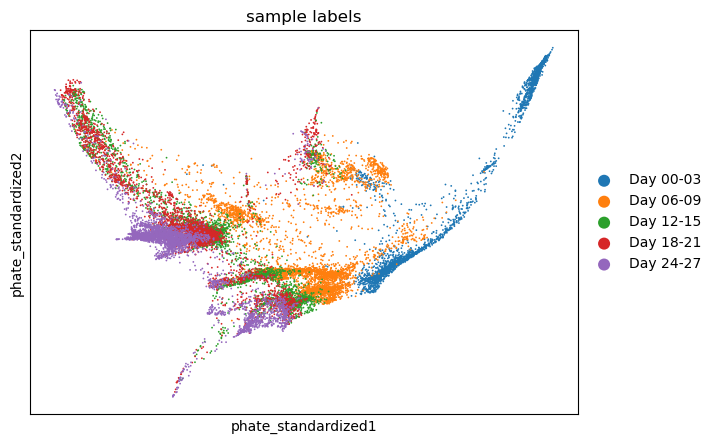

In [190]:
sc.pl.scatter(adata, basis="phate_standardized", color=label)

In [182]:
adata.obs[label].cat.codes.unique()

array([0, 1, 2, 3, 4], dtype=int8)